In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [9]:
from mppi import Parsers as P, Optics as O
from mppi.Utilities import Constants as C, Utils as U
from mppi.Utilities import FourierTransform as FT
import matplotlib.pyplot as plt
import numpy as np
import os

# Analysis of the Optics modules

This notebook describes the various modules of the package built in order to extract both the linear and non-linear optical properties of a system
from the knowledge of the real-time polarization.

## Linear response analysis

We show how to compute the linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF in the linear response regime using a delta-shaped pulse

In [34]:
file = 'Reference_data/nl_results/LiF-delta_pulse/ndb.Nonlinear'

In [35]:
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-delta_pulse/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [12]:
time_fs = data.get_time() # in fs
time_au = data.IO_TIME_points
P_t = data.Polarization[0]
efield = data.Efield[0]
t_initial_au=efield["initial_time"]
t_initial_fs = t_initial_au/C.FsToAu

The module can deal with both time variables expressed in fs or in au.

The damp_ft function applies a damping in the time domain to produce a spread in the frequency domain and avoid 
spurious oscillations of the optical quantities.
The damping eta is expressed in eV

In [13]:
P_damped = U.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.1,time_units='fs')

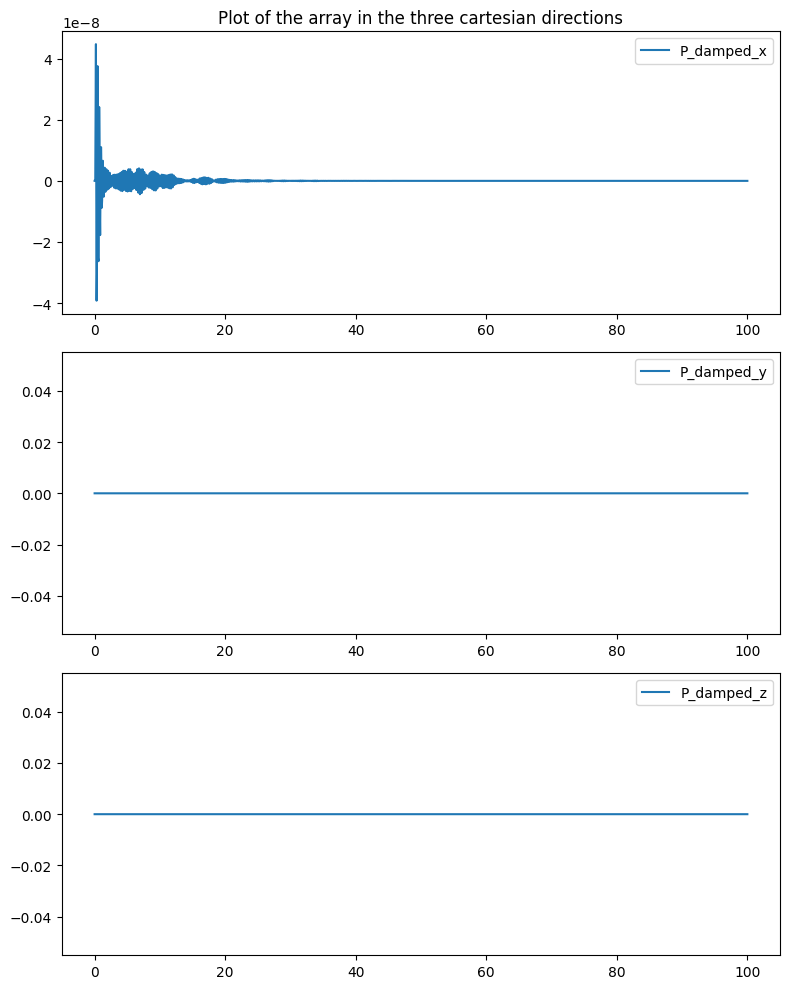

In [14]:
U.Plot_3dArray(time_fs,P_damped,label='P_damped')

The linear response is computed by the Linear_response function of the module

In [15]:
energy,chi = O.Linear_Response(time_fs,P_t,efield=efield,eta=0.1,time_units='fs')

Time units = fs. Rescaled to au


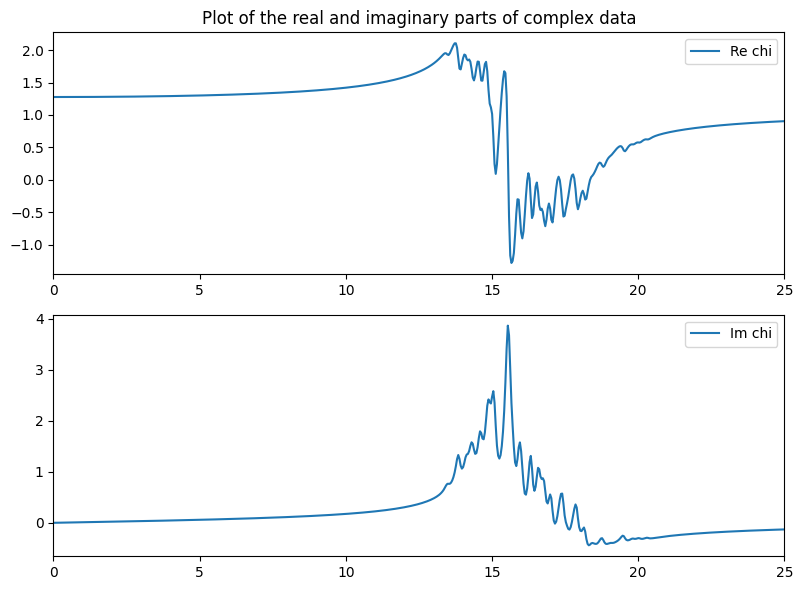

In [16]:
U.Plot_ComplexArray(energy,chi,xlim=(0,25),label='chi')

## Non-linear analysis for a sine-shaped pulse

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [ ]:
file = 'Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [18]:
nl = O.Xn_single_frequency(data,Trange=[-1,-1],X_order=3,inactive_harmonics=None)

Time range of the simulation (in au): 0.0 - 8268.274667312273
Time range of the simulation (in fs): 0.0 - 200.00000162820604
Type of the external field: SIN
Order of the non-linear susceptibility extracted: 3
Number of frequencies: 50
Frequency range of the field (in Hartree): 0.18374663009599138 - 0.9040334200722775
Frequency range of the field (in eV): 5.000000477741239 - 24.600002350486893
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 3265.3660079999995 au 78.98542721355673 fs


In [19]:
iT = nl.set_time_sampling(0)
nl.time[iT[0]]/C.FsToAu,nl.time[iT[1]]/C.FsToAu

(np.float64(199.170001621449), np.float64(200.00000162820604))

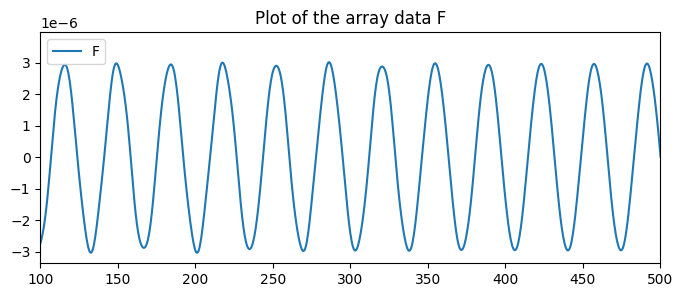

In [20]:
U.Plot_Array(nl.time,nl.pol[0,0,:],xlim=(100,500),figsize=(8,3))

In [21]:
A,phi,B0,res = nl.perform_harmonic_analysis(0)
A.shape

(3, 3)

In [22]:
A,phi,B0

(array([[2.95772108e-06, 0.00000000e+00, 0.00000000e+00],
        [5.41938024e-12, 0.00000000e+00, 0.00000000e+00],
        [2.81693376e-12, 0.00000000e+00, 0.00000000e+00]]),
 array([[-0.80104391,  0.        ,  0.        ],
        [-1.83221085,  0.        ,  0.        ],
        [ 0.4173221 ,  0.        ,  0.        ]]),
 array([7.00321623e-13, 0.00000000e+00, 0.00000000e+00]))

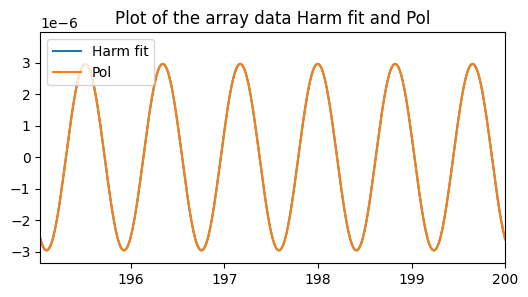

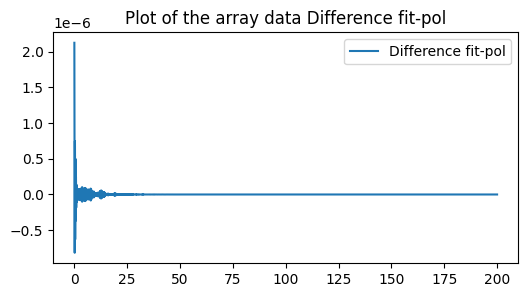

In [23]:
nl.check_harmonic_reliability(plot_ifreq=0)

In [27]:
chi = nl.compute_Xn(plot=False,set_units_of_measure=True)
chi.shape

(4, 50, 3)

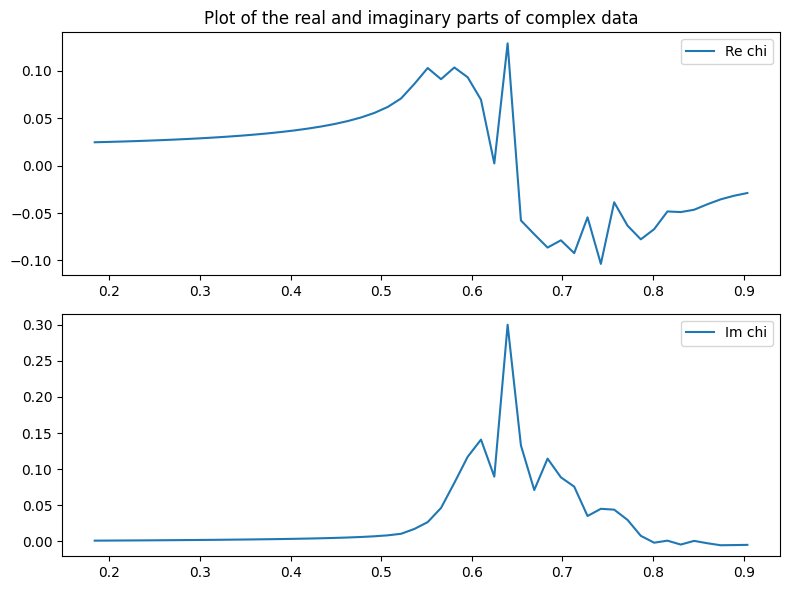

In [28]:
U.Plot_ComplexArray(nl.fields_freqs,chi[1,:,0],label='chi')

We compare this result with the one of the YamboPy module

In [30]:
from mppi.Optics import NLanalysisYamboPy as NLYP

In [31]:
SIG = NLYP.Xn_from_sine(data,X_order=3,solver='lstsq',nsamp=-1,debug_mode=False) #,T_range=[10*C.FsToAu,200*C.FsToAu]
#,T_range=[50.0*C.FsToAu,100.0*C.FsToAu]
print(SIG)


 * * *  Xn from signal class  * * * 

Max time: 8268.274667312273
Time step : 0.4134137333656136
Type Efield    : SIN
Number of runs   : 50
Max harmonic order   : 3
Solver           : lstsq
Frequency range: [0.18374663009599138,0.9040334200722775] [au] 



In [32]:
out = SIG.perform_analysis()
freqs,chi_yp = SIG.output_analysis(out)

100%|█████████████████| 50/50 [00:00<00:00, 1480.57it/s]

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic o

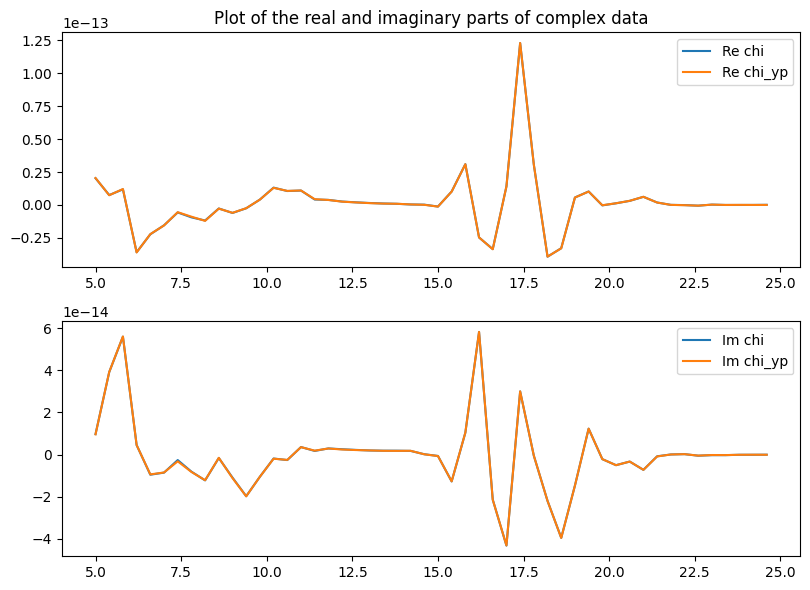

In [33]:
harm = 3
U.Plot_ComplexArray(nl.fields_freqs*C.HaToeV,chi[harm,:,0],label='chi',data2=chi_yp[harm,:,0],label2='chi_yp')

## Non-linear analysis for frequency mixing

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [17]:
file = 'Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [18]:
nl = O.Xn_single_frequency(data,Trange=[-1,-1],X_order=3,inactive_harmonics=None)

Time range of the simulation (in au): 0.0 - 8268.274667312273
Time range of the simulation (in fs): 0.0 - 200.00000162820604
Type of the external field: SIN
Order of the non-linear susceptibility extracted: 3
Number of frequencies: 50
Frequency range of the field (in Hartree): 0.18374663009599138 - 0.9040334200722775
Frequency range of the field (in eV): 5.000000477741239 - 24.600002350486893
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 3265.3660079999995 au 78.98542721355673 fs
